<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-08/Practical-08-Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 08

## Aim

To apply regularization techniques such as Ridge Regression and Lasso Regression to reduce overfitting and improve the generalization performance of a machine learning model.

In [3]:
# Practical 08
# Apply Regularization to Avoid Overfitting

print("Practical 08: Regularization to Avoid Overfitting")

Practical 08: Regularization to Avoid Overfitting


## Theory

Regularization is a technique used in machine learning to prevent **overfitting**. Overfitting occurs when a model learns the training data too closely and performs poorly on unseen data.

Regularization adds a penalty to the model's loss function. This penalty discourages the model from assigning excessively large values to the coefficients and helps improve its generalization ability.

Two commonly used regularization techniques are:

### 1. Ridge Regression (L2 Regularization)

Ridge Regression adds a penalty equal to the squared magnitude of the coefficients.

**Formula:**

J(β) = Σ(yᵢ − ŷᵢ)² + α Σβⱼ²

Ridge regression reduces the magnitude of coefficients but generally does not make them exactly zero.

### 2. Lasso Regression (L1 Regularization)

Lasso Regression adds a penalty equal to the absolute magnitude of the coefficients.

**Formula:**

J(β) = Σ(yᵢ − ŷᵢ)² + α Σ|βⱼ|

Lasso can reduce some coefficients exactly to zero, making it useful for feature selection.

### Regularization Parameter

The parameter **α (alpha)** controls the strength of regularization.

- Small α → weaker regularization
- Large α → stronger regularization

Regularization helps reduce model complexity and improves performance on unseen data.

In [4]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Load the Diabetes dataset

diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature Names:")
print(list(X.columns))

print("\nFirst 5 records:")
display(X.head())

print("\nTarget values:")
display(y.head())

Dataset loaded successfully.
Number of samples: 442
Number of features: 10

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

First 5 records:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target values:


,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [7]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed successfully.")

Feature standardization completed successfully.


In [8]:
# Ridge Regression (L2 Regularization)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_predictions = ridge_model.predict(X_test_scaled)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [9]:
# Evaluate Ridge Regression

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Performance")
print("--------------------------------")
print("MAE  :", round(ridge_mae, 4))
print("MSE  :", round(ridge_mse, 4))
print("RMSE :", round(ridge_rmse, 4))
print("R² Score :", round(ridge_r2, 4))
print("R² Score (%) :", round(ridge_r2 * 100, 2), "%")

Ridge Regression Performance
--------------------------------
MAE  : 42.812
MSE  : 2892.0146
RMSE : 53.7775
R² Score : 0.4541
R² Score (%) : 45.41 %


In [10]:
# Lasso Regression (L1 Regularization)

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_scaled, y_train)

lasso_predictions = lasso_model.predict(X_test_scaled)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [11]:
# Evaluate Lasso Regression

lasso_mae = mean_absolute_error(y_test, lasso_predictions)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Performance")
print("--------------------------------")
print("MAE  :", round(lasso_mae, 4))
print("MSE  :", round(lasso_mse, 4))
print("RMSE :", round(lasso_rmse, 4))
print("R² Score :", round(lasso_r2, 4))
print("R² Score (%) :", round(lasso_r2 * 100, 2), "%")

Lasso Regression Performance
--------------------------------
MAE  : 42.803
MSE  : 2824.5681
RMSE : 53.1467
R² Score : 0.4669
R² Score (%) : 46.69 %


In [12]:
# Compare Ridge and Lasso Regression

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Ridge Regression": [
        ridge_mae,
        ridge_mse,
        ridge_rmse,
        ridge_r2
    ],
    "Lasso Regression": [
        lasso_mae,
        lasso_mse,
        lasso_rmse,
        lasso_r2
    ]
})

display(comparison)

,Metric,Ridge Regression,Lasso Regression
0,MAE,42.811999,42.802984
1,MSE,2892.014566,2824.568094
2,RMSE,53.777454,53.146666
3,R² Score,0.454147,0.466877


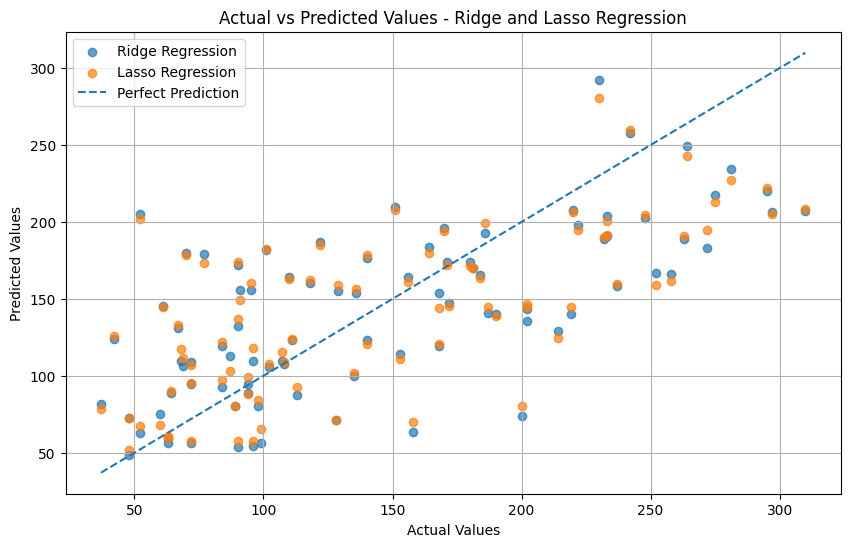

In [13]:
# Actual vs Predicted Values

plt.figure(figsize=(10, 6))

plt.scatter(y_test, ridge_predictions, label="Ridge Regression", alpha=0.7)
plt.scatter(y_test, lasso_predictions, label="Lasso Regression", alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Ridge and Lasso Regression")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Compare Ridge and Lasso Coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_model.coef_,
    "Lasso Coefficient": lasso_model.coef_
})

display(coefficients)

,Feature,Ridge Coefficient,Lasso Coefficient
0,age,1.807342,0.687032
1,sex,-11.448190,-9.297519
2,bmi,25.732699,26.219225
3,bp,16.734300,15.657314
4,s1,-34.671954,-8.228172
5,s2,17.053075,-0.000000
6,s3,3.369914,-9.024087
7,s4,11.764260,3.420861
8,s5,31.378384,22.636465
9,s6,2.458139,2.098647


In [15]:
# Count zero coefficients in Lasso Regression

zero_coefficients = np.sum(lasso_model.coef_ == 0)

print("Total number of features:", len(lasso_model.coef_))
print("Number of zero coefficients in Lasso:", zero_coefficients)
print("Number of non-zero coefficients in Lasso:", len(lasso_model.coef_) - zero_coefficients)

Total number of features: 10
Number of zero coefficients in Lasso: 1
Number of non-zero coefficients in Lasso: 9


In [16]:
# Effect of Regularization Parameter (Alpha)

alphas = [0.01, 0.1, 1, 10, 100]

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_scores.append(r2_score(y_test, ridge_pred))

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_pred = lasso.predict(X_test_scaled)
    lasso_scores.append(r2_score(y_test, lasso_pred))

print("Alpha values:", alphas)
print("Ridge R² Scores:", [round(score, 4) for score in ridge_scores])
print("Lasso R² Scores:", [round(score, 4) for score in lasso_scores])

Alpha values: [0.01, 0.1, 1, 10, 100]
Ridge R² Scores: [0.4526, 0.4528, 0.4541, 0.4572, 0.4605]
Lasso R² Scores: [0.4529, 0.4555, 0.4669, 0.4463, -0.012]


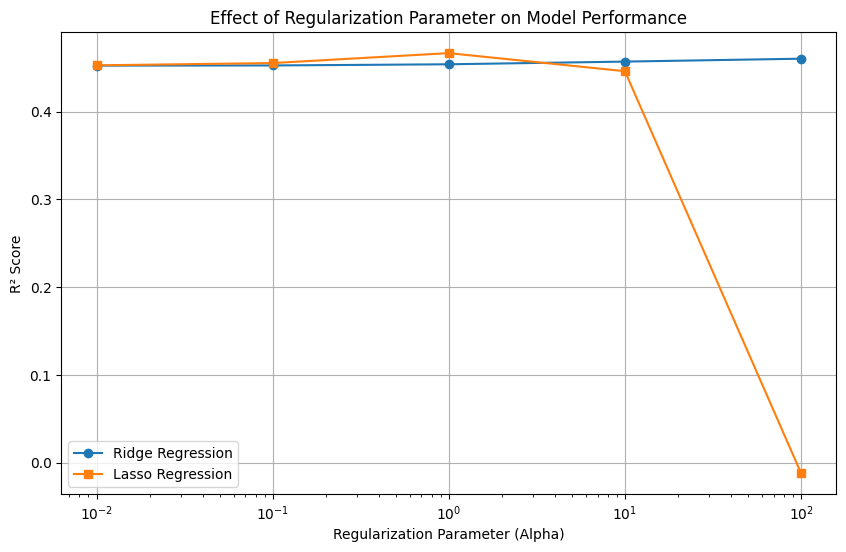

In [17]:
# Plot R² Score for Different Alpha Values

plt.figure(figsize=(10, 6))

plt.plot(alphas, ridge_scores, marker='o', label="Ridge Regression")
plt.plot(alphas, lasso_scores, marker='s', label="Lasso Regression")

plt.xscale("log")
plt.xlabel("Regularization Parameter (Alpha)")
plt.ylabel("R² Score")
plt.title("Effect of Regularization Parameter on Model Performance")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

In this practical, Ridge Regression and Lasso Regression were successfully implemented using the Diabetes dataset to study the effect of regularization on a regression model.

Ridge Regression uses **L2 regularization**, while Lasso Regression uses **L1 regularization**. Regularization helps control model complexity by penalizing large coefficient values and thereby reduces the risk of overfitting.

The performance of both models was evaluated using **MAE, MSE, RMSE, and R² Score**. The effect of different regularization parameter values (α) was also analyzed using graphical visualization.

The results demonstrate that regularization can improve the generalization ability of machine learning models and helps in building more stable and reliable predictive models.

## Result

Ridge Regression and Lasso Regression were successfully applied to the Diabetes dataset. The models were evaluated using standard regression metrics, and the effect of the regularization parameter α was analyzed. The practical demonstrates how regularization helps control model complexity and reduce overfitting.